In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
# from scipy.interpolate import RegularGridInterpolator
import MITgcmutils as mitgcm
import xmitgcm 
from xmitgcm.utils import read_mds

%matplotlib inline
import os
import imageio
import pandas as pd

import sys
from contextlib import contextmanager

import ttide as tt
from tqdm import tqdm
import psutil
import math
import gc

# for out diag files

In [3]:
def get_ram_info():
    """
    Retrieves and prints detailed information about the system's RAM usage.
    """
    mem = psutil.virtual_memory()
    
    # Helper function to format bytes into human-readable units (GB)
    bytes_to_gb = lambda bytes_val: math.ceil(bytes_val / (1024**3))

    # print(f"Total RAM      : {bytes_to_gb(mem.total)} GB")
    # print(f"Available RAM  : {bytes_to_gb(mem.available)} GB")
    print(f"Used RAM  : {mem.used}")
    # print(f"Used RAM       : {bytes_to_gb(mem.used)} GB")
    # print(f"Used Percentage: {mem.percent}%")

get_ram_info()

Used RAM  : 4420079616


In [4]:
drF = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/DRF',)
hFacW = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/hFacW',)
XC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/XC',)
YC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/YC',)

In [51]:
u_ts = []

for it in range(500,530):
    print(f'Processing time step: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u_ts.append(u2d_2)

# convert u_ts to xarray dataset and save as netcdf
u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
u_ts_da.to_netcdf('case_ctrl/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step: 500
Processing time step: 501
Processing time step: 502
Processing time step: 503
Processing time step: 504
Processing time step: 505
Processing time step: 506
Processing time step: 507
Processing time step: 508
Processing time step: 509
Processing time step: 510
Processing time step: 511
Processing time step: 512
Processing time step: 513
Processing time step: 514
Processing time step: 515
Processing time step: 516
Processing time step: 517
Processing time step: 518
Processing time step: 519
Processing time step: 520
Processing time step: 521
Processing time step: 522
Processing time step: 523
Processing time step: 524
Processing time step: 525
Processing time step: 526
Processing time step: 527
Processing time step: 528
Processing time step: 529


/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [71]:
u_ts = []

for it in range(500,530):
    print(f'Processing time step for BT case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['UVEL'][0,:,:]
    u_ts.append(u2d_2)

# convert u_ts to xarray dataset and save as netcdf
u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BT case: 500
Processing time step for BT case: 501
Processing time step for BT case: 502
Processing time step for BT case: 503
Processing time step for BT case: 504
Processing time step for BT case: 505
Processing time step for BT case: 506
Processing time step for BT case: 507
Processing time step for BT case: 508
Processing time step for BT case: 509
Processing time step for BT case: 510
Processing time step for BT case: 511
Processing time step for BT case: 512
Processing time step for BT case: 513
Processing time step for BT case: 514
Processing time step for BT case: 515
Processing time step for BT case: 516
Processing time step for BT case: 517
Processing time step for BT case: 518
Processing time step for BT case: 519
Processing time step for BT case: 520
Processing time step for BT case: 521
Processing time step for BT case: 522
Processing time step for BT case: 523
Processing time step for BT case: 524
Processing time step for BT case: 525
Processing t

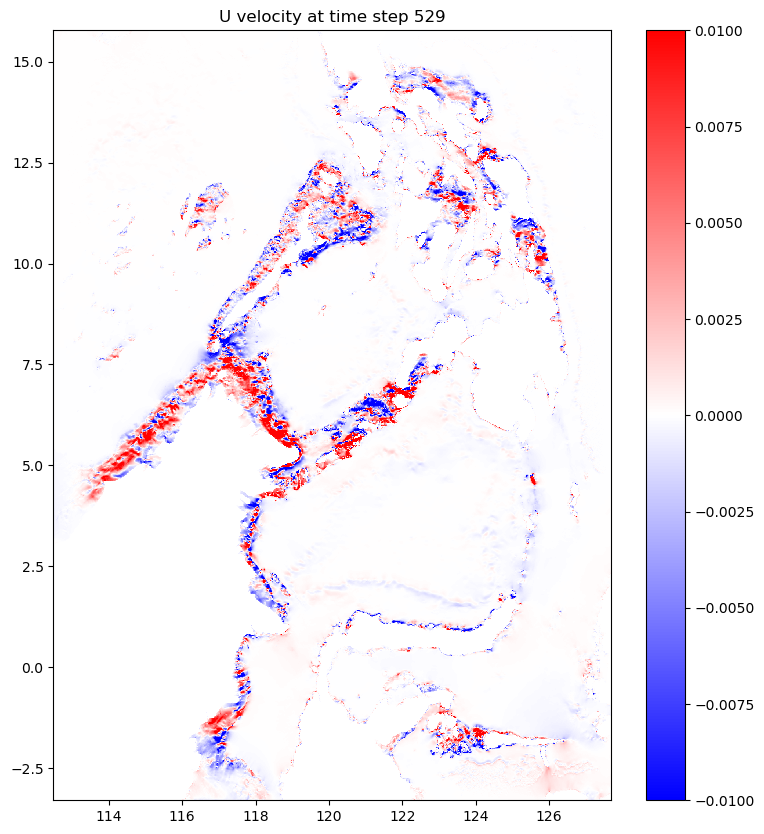

In [66]:
#check saved netcdf
ds_check = xr.open_dataset('case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_check['__xarray_dataarray_variable__']

fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for i in range(30):
    ax.clear()
    cs = ax.pcolormesh(ds_bt.XG, ds_bt.YC, ds_check['__xarray_dataarray_variable__'].isel(time=i),vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'U velocity at time step {500+i}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/u_2d_frombc_t_500_to_530_{i}.png')


In [74]:
fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for it in range(500,530):
    print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['UVEL'][0,:,:]
    # u_ts.append(u2d_2)

    ax.clear()
    cs = ax.pcolormesh(ds_bt.XG, ds_bt.YC, u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'Usur velocity at time step {it}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/usur_frombc_t_500_to_530_{it}.png')
# # convert u_ts to xarray dataset and save as netcdf
# u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
# u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BC case: 500
Processing time step for BC case: 501
Processing time step for BC case: 502
Processing time step for BC case: 503
Processing time step for BC case: 504
Processing time step for BC case: 505
Processing time step for BC case: 506
Processing time step for BC case: 507
Processing time step for BC case: 508
Processing time step for BC case: 509
Processing time step for BC case: 510
Processing time step for BC case: 511
Processing time step for BC case: 512
Processing time step for BC case: 513
Processing time step for BC case: 514
Processing time step for BC case: 515
Processing time step for BC case: 516
Processing time step for BC case: 517
Processing time step for BC case: 518
Processing time step for BC case: 519
Processing time step for BC case: 520
Processing time step for BC case: 521
Processing time step for BC case: 522
Processing time step for BC case: 523
Processing time step for BC case: 524
Processing time step for BC case: 525
Processing t

: 

: 

: 

Processing time step for BC case: 500


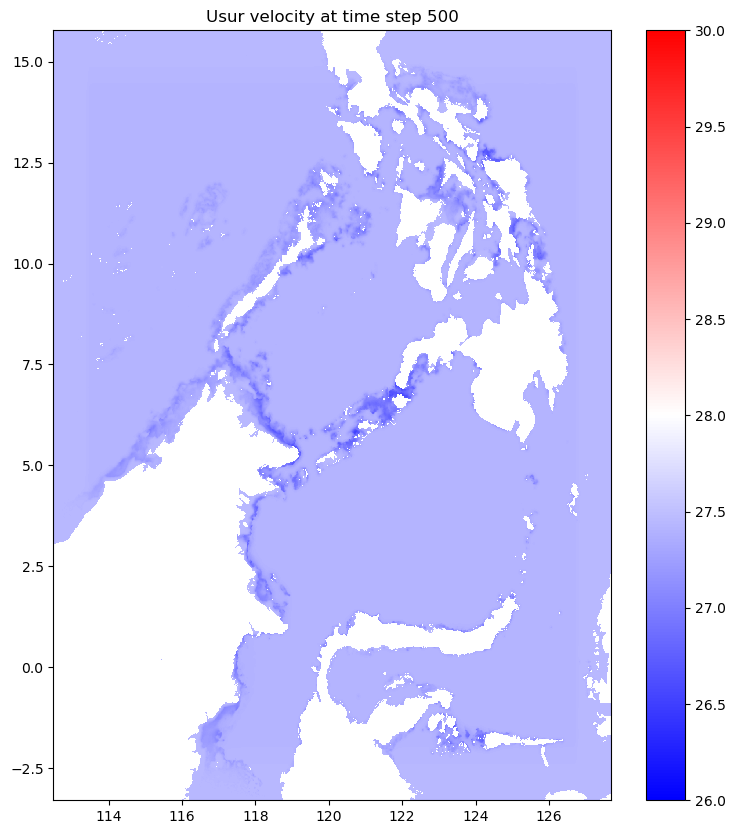

In [18]:
fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for it in range(500,501):
    print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['THETA'][0,:,:]

    # u_ts.append(u2d_2)
    u2d_2[u2d_2==0]=np.nan
    ax.clear()
    cs = ax.pcolormesh(XC['XC'], YC['YC'], u2d_2,vmax=30, vmin=26,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'Usur velocity at time step {it}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/tsur_frombc_t_500_to_530_{it}.png')
# # convert u_ts to xarray dataset and save as netcdf
# u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
# u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

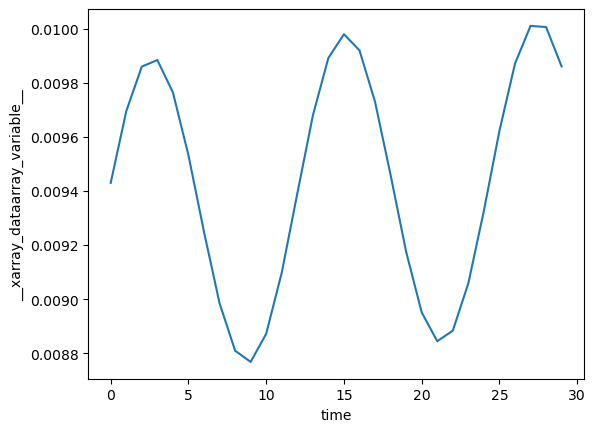

In [69]:
ds_check['__xarray_dataarray_variable__'].isel(XG=600, YC=900).plot()

In [ ]:
icase = '075'

nt = 570


In [ ]:
ds_eta = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',prefix=['outs_sn_etan'])
# ds_eta

ds_sn = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',prefix=['outs_sn'])
ds_sn

<xarray.Dataset> Size: 2TB
Dimensions:  (XC: 1520, YC: 1908, XG: 1520, YG: 1908, Z: 57, Zp1: 58, Zu: 57,
              Zl: 57, time: 575)
Coordinates: (12/37)
  * XC       (XC) >f4 6kB 112.5 112.5 112.5 112.5 ... 127.7 127.7 127.7 127.7
  * YC       (YC) >f4 8kB -3.295 -3.285 -3.275 -3.265 ... 15.76 15.77 15.77
  * XG       (XG) >f4 6kB 112.5 112.5 112.5 112.5 ... 127.7 127.7 127.7 127.7
  * YG       (YG) >f4 8kB -3.3 -3.29 -3.28 -3.27 ... 15.74 15.75 15.76 15.77
  * Z        (Z) >f4 228B -12.5 -37.5 -62.5 ... -4.062e+03 -4.453e+03 -4.908e+03
  * Zp1      (Zp1) >f4 232B 0.0 -25.0 -50.0 ... -4.247e+03 -4.658e+03 -5.158e+03
    ...       ...
    maskInW  (YC, XG) bool 3MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    dxF      (YC, XC) >f4 12MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    maskInC  (YC, XC) bool 3MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    maskInS  (YG, XC) bool 3MB dask.array<chunksize=(1908, 1520), meta=np.ndarray>
    iter     (time) int64 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time     (time) timedelta64[ns] 5kB 00:00:00 00:03:00 ... 1 days 04:42:00
Data variables:
    UVEL     (time, Z, YC, XG) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    THETA    (time, Z, YC, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    PHIHYD   (time, Z, YC, XC) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='/home/ceoas/l...

## 1. plot ETA and make GIF

In [ ]:
fig_folder = f'case_N2_fac_{icase}'
try:
    os.makedirs(fig_folder, exist_ok=True)
    print(f"Folder '{fig_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{fig_folder}' : {e}.")

lon = ds_eta.XC
lat = ds_eta.YC

# t0 = diff_eta.time[0].values*10/np.timedelta64(1, 'h')

for it in range(0,33):
    # ds_eta = xmitgcm.open_mdsdataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/res100_runs/dt_exp3_depth_v1',iters = [it*10],prefix=['outs_sn_etan'])
    eplt = ds_eta.isel(time=it).ETAN
    eplt = eplt.where(eplt!=0,np.nan)
    t0 = ds_eta.time[it].values*20/np.timedelta64(1, 'h')
    fig = plt.figure(figsize=(8,7))
    # plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-3,3.2,0.2))
    plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-0.035,0.036,0.001))
    plt.xlabel('Longitude ($^o$E)')
    plt.ylabel('Latitude ($^o$N)')
    plt.colorbar()
    plt.title(f'Eta of CASE {icase} at {t0:4f} hours')
    # plt.ylim(-3.3,0)
    # plt.xlim(116,120)
    
    plt.savefig(f'{fig_folder}/eta_it{it:03d}.png')
    fig.clear()
    plt.close(fig)
    get_ram_info()

Folder 'case_N2_fac_033' created.
Used RAM  : 22175195136
Used RAM  : 24305463296
Used RAM  : 25407795200
Used RAM  : 26899374080
Used RAM  : 26356908032
Used RAM  : 26444967936
Used RAM  : 26590818304
Used RAM  : 25278533632
Used RAM  : 25258553344
Used RAM  : 24694845440
Used RAM  : 25627561984
Used RAM  : 26296455168
Used RAM  : 26391851008
Used RAM  : 26485506048
Used RAM  : 26536357888
Used RAM  : 26537013248
Used RAM  : 26541744128
Used RAM  : 26548080640
Used RAM  : 26618073088
Used RAM  : 26226413568
Used RAM  : 26090663936
Used RAM  : 26446778368
Used RAM  : 26334121984
Used RAM  : 26307166208
Used RAM  : 24428351488
Used RAM  : 25250246656
Used RAM  : 25878380544
Used RAM  : 25746649088
Used RAM  : 25408221184
Used RAM  : 24814608384
Used RAM  : 24293310464
Used RAM  : 24438251520
Used RAM  : 23301099520


In [ ]:
# Create a GIF from the saved PNG images
# fig_folder = 'exp4_results/eta_exp4_2timesN2_M2_dt5s_v1'
itmax=72
idt=1
png_files = [f'{fig_folder}/eta_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the gif
    with imageio.get_writer(f'{fig_folder}/eta_animation_m2_v1.gif', mode='I',palettesize=64, duration=500.0, loop=0) as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created GIF with {len(existing_files)} frames at '{fig_folder}/eta_animation_m2_v1.gif'")
else:
    print("No PNG files found to create GIF.")

Created GIF with 72 frames at 'case_N2_fac_033/eta_animation_m2_v1.gif'


In [ ]:
# Create an MP4 from the saved PNG images
# fig_folder = 'exp8_results/eta_exp8_exp7_diff'
fig_folder = f'case_N2_fac_{icase}'
itmax=72
idt=1
png_files = [f'{fig_folder}/eta_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the mp4 (1 second per frame = 1 fps)
    with imageio.get_writer(f'{fig_folder}/eta_animation_m2_v1.mp4', fps=1.5, codec='libx264') as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created MP4 with {len(existing_files)} frames at '{fig_folder}/eta_animation_m2_v1.mp4'")
else:
    print("No PNG files found to create MP4.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 700) to (800, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Created MP4 with 72 frames at 'case_N2_fac_033/eta_animation_m2_v1.mp4'


In [ ]:
fig_folder = 'exp8_results/eta_exp8'
try:
    os.makedirs(fig_folder, exist_ok=True)
    print(f"Folder '{fig_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{fig_folder}' : {e}.")


lon = ds_eta_exp8.XC
lat = ds_eta_exp8.YC

# t0 = diff_eta.time[0].values*10/np.timedelta64(1, 'h')

for it in range(0,124,2):
    # ds_eta = xmitgcm.open_mdsdataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/res100_runs/dt_exp3_depth_v1',iters = [it*10],prefix=['outs_sn_etan'])
    eplt = ds_eta_exp8.ETAN.isel(time=it)
    eplt = eplt.where(eplt!=0,np.nan)
    t0 = ds_eta_exp8.time[it].values*20/np.timedelta64(1, 'h')
    plt.figure(figsize=(8,7))
    # plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-3,3.2,0.2))
    plt.contourf(lon,lat,eplt,cmap='RdBu',levels=np.arange(-0.035,0.036,0.001))
    plt.xlabel('Longitude ($^o$E)')
    plt.ylabel('Latitude ($^o$N)')
    plt.colorbar()
    plt.title(f'Eta of exp8 at {t0:4f} hours')
    # plt.ylim(-3.3,0)
    # plt.xlim(116,120)
    
    plt.savefig(f'{fig_folder}/eta_it{it:03d}.png')
    plt.close()

Folder 'exp8_results/eta_exp8' created.


## 2. plot temp at 150 m and make GIF

In [ ]:
fig_folder = f'case_N2_fac_{icase}'

t_case = ds_sn.THETA.isel(time = slice(0,nt),Z=5)
# tref
for it in tqdm(range(nt)):
    ds_tref0 = xr.open_dataset(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc')
    if it==0:
        ds_tref = ds_tref0
    else:
        ds_tref = xr.concat([ds_tref,ds_tref0],"t")

ds_tref['t'] = ds_sn.time[0:nt]
# ds_tref
tref = ds_tref.theta_ref[:,5]

try:
    os.makedirs(fig_folder, exist_ok=True)
    print(f"Folder '{fig_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{fig_folder}' : {e}.")

lon = ds_sn.XC
lat = ds_sn.YC

fig, ax = plt.subplots(figsize=(8,7))
cbar = None

for it in range(0,190,2):
    # ds_sn = xmitgcm.open_mdsdataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/res100_runs/dt_exp3_depth_v1/',prefix=['outs_sn'], iters = [it*720])
    # t0 = ds_sn.time[it].values*100/np.timedelta64(1, 'h')
    # temp = (temp100.isel(time=it)-temp100.isel(time=0)).values
    t0 = ds_sn.time[it].values*20/np.timedelta64(1, 'h')
    # temp = (ds_sn.THETA.isel(time=0,Z=5)-ds_sn0.THETA.isel(time=0,Z=5)).values
    # temp = diff_t.isel(time=it).values
    temp = (t_case.isel(time=it).where(t_case.isel(time=it)!=0)-tref.isel(t=it)).values
    # temp[temp==0] = np.nan
    ax.clear()
    cs = ax.contourf(lon,lat,temp,cmap='RdBu_r',levels=np.arange(-0.05,0.052,0.005),extend='both')
    ax.set_xlabel('Longitude ($^o$E)')
    ax.set_ylabel('Latitude ($^o$N)')
    ax.set_title(f'Temp-T_ref (small_perturb) at {t0:4f} hours')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    
    del temp, cs
    gc.collect()
    
    plt.savefig(f'{fig_folder}/temp_anom_it{it:03d}.png')
    get_ram_info()

plt.close(fig)
del fig, ax, cbar

100%|██████████| 570/570 [00:06<00:00, 86.22it/s] 


Folder 'case_N2_fac_075' created.
Used RAM  : 6647984128
Used RAM  : 6699438080
Used RAM  : 6756605952
Used RAM  : 6756147200
Used RAM  : 6768009216
Used RAM  : 6736490496
Used RAM  : 6765756416
Used RAM  : 6738763776
Used RAM  : 6767591424
Used RAM  : 6751358976
Used RAM  : 6768271360
Used RAM  : 6749782016
Used RAM  : 6779691008
Used RAM  : 6741688320
Used RAM  : 6768525312
Used RAM  : 6750707712
Used RAM  : 6772690944
Used RAM  : 6747525120
Used RAM  : 6776844288
Used RAM  : 6766374912
Used RAM  : 6776332288
Used RAM  : 6756712448
Used RAM  : 6784630784
Used RAM  : 6739460096
Used RAM  : 6764163072
Used RAM  : 6733168640
Used RAM  : 6759591936
Used RAM  : 6743470080
Used RAM  : 6762700800
Used RAM  : 6735638528
Used RAM  : 6775193600
Used RAM  : 6737436672
Used RAM  : 6771671040
Used RAM  : 6745960448
Used RAM  : 6773989376
Used RAM  : 6747869184
Used RAM  : 6762356736
Used RAM  : 6749097984
Used RAM  : 6770860032
Used RAM  : 6761463808
Used RAM  : 6778470400
Used RAM  : 6754324480


(-500.0, 0.0)

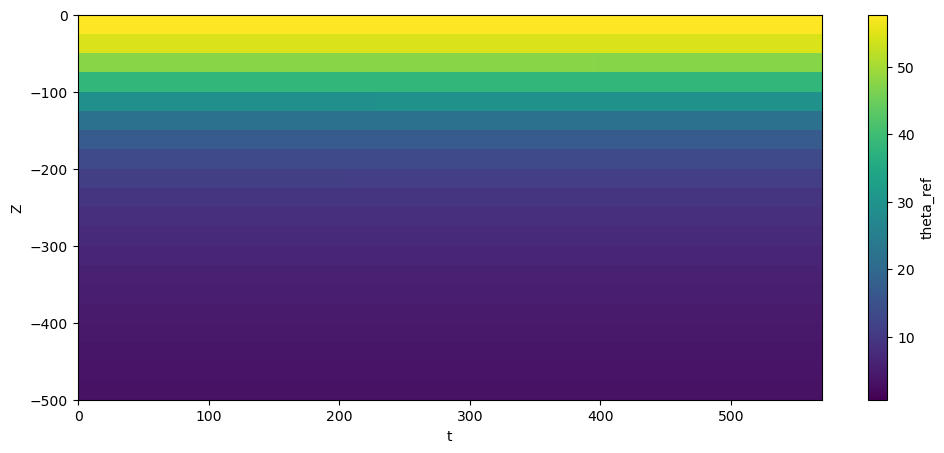

In [ ]:
plt.figure(figsize=(12,5))
ds_tref.theta_ref.T.plot()
plt.ylim(-500,0)

In [ ]:
# GIF
# Create a GIF from the saved PNG images
itmax=96
idt=1
png_files = [f'{fig_folder}/temp_anom_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the gif
    with imageio.get_writer(f'{fig_folder}/temp_anom_animation_m2_v1.gif', mode='I',palettesize=64, duration=500.0, loop=0) as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created GIF with {len(existing_files)} frames at '{fig_folder}/temp_anom_nimation_m2_v1.gif'")
else:
    print("No PNG files found to create GIF.")

Created GIF with 97 frames at 'exp8_results/temp_z5_exp8/temp_anom_nimation_m2_v1.gif'


In [ ]:
# MP4
# Create an MP4 from the saved PNG images
# fig_folder = 'exp4_results/eta_exp4_2timesN2_M2_dt5s_v1'
itmax=193
idt=1
png_files = [f'{fig_folder}/temp_anom_it{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the mp4 (1 second per frame = 1 fps)
    with imageio.get_writer(f'{fig_folder}/temp_anom_animation_m2_v1.mp4', fps=1.5, codec='libx264') as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created MP4 with {len(existing_files)} frames at '{fig_folder}/temp_anom_animation_m2_v1.mp4'")
else:
    print("No PNG files found to create MP4.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 700) to (800, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Created MP4 with 95 frames at 'case_N2_fac_075/temp_anom_animation_m2_v1.mp4'


# get elevation data

[12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.
 30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65.
 66. 67. 68. 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83.
 84. 85. 86. 87. 88. 89. 90. 91. 92. 93. 94. 95. 96.]


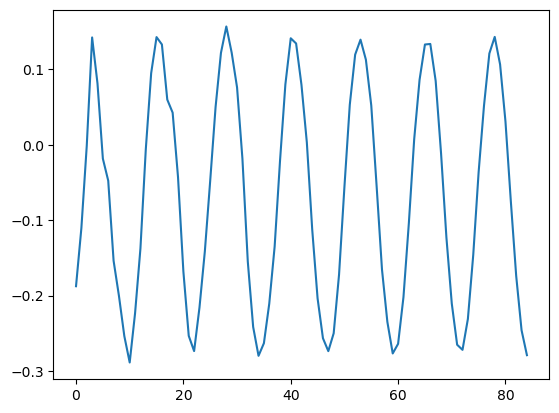

In [ ]:
ttseries = (ds_eta.time.values*5/np.timedelta64(1, 'h'))[12:]
etseries = ds_eta.ETAN.isel(XC=2,YC=1000).values[12:]
plt.plot(etseries)
# etseries = ds_eta.ETAN.isel(XC=20,YC=1000).values[20:]
# plt.plot(etseries)
# etseries = ds_eta.ETAN.isel(XC=200,YC=1000).values[20:]
# plt.plot(etseries)

print(ttseries)

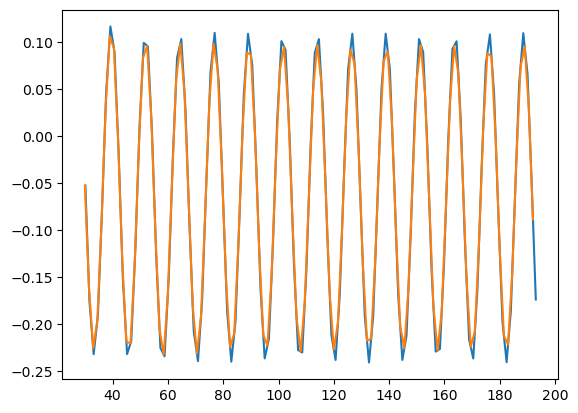

In [ ]:
t1 = np.arange(30,193,1.5)
etseries_interp = np.interp(t1,ttseries, etseries)
plt.plot(ttseries, etseries)
plt.plot(t1,etseries_interp)

In [ ]:
temp100 = ds_sn.THETA.isel(Z=5)
temp_t = temp100.isel(XC=2,YC=1000)
temp_t2 = temp100.isel(XC=200,YC=1000)

In [ ]:
# ttseries = (ds_eta.time.values*100/np.timedelta64(1, 'h'))
# plt.plot(ttseries,temp_t)
# plt.plot(ttseries,temp_t2)
# ttseries

temp_t.plot()
temp_t2.plot()

In [ ]:

@contextmanager
def suppress_stdout():
    """Context manager to suppress printing to standard output."""
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

# t1 = np.arange(30,193,1.5)
# ttseries = (ds_sn.time.values*100/np.timedelta64(1, 'h'))[12:]
# t = np.arange(0, 30*24, 1)   # 30 days hourly
# # t = pd.to_datetime(np.arange(0, 100*24, 0.5), unit='h', origin='2023-01-01')

# # Two tidal constituents: M2 (12.42h), S2 (12.00h)
# # signal = 1.5 * np.cos(2*np.pi*t.hour/12.42) + 0.5 * np.cos(2*np.pi*t.hour/12.0 + np.pi/4)
# signal = 2.5 * np.cos(2*np.pi*t/12.42)
amp_m2_model = np.zeros((1520,1908))
pha_m2_model = np.zeros((1520,1908))
for ii in range(0,1908,20):
    print(ii)
    for jj in range(0,1520,20):
        etseries = ds_eta.ETAN.isel(XC=jj,YC=ii).values[12:]
        # etseries_interp = np.interp(t1,ttseries, etseries)
        with suppress_stdout():
            # Any print statements within this block will be suppressed
            xout = tt.t_tide(etseries,dt=1,constitnames=['M2'])
    
        amp_m2_model[jj,ii] = xout['tidecon'][0][0]
        pha_m2_model[jj,ii] = xout['tidecon'][0][2]

0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480
500
520
540
560
580
600
620
640
660
680
700
720
740
760
780
800
820
840
860
880
900
920
940
960
980
1000
1020
1040
1060
1080
1100
1120
1140
1160
1180
1200
1220
1240
1260
1280
1300
1380
1400
1420
1440
1460
1480
1500
1520
1540
1560
1580
1600
1620
1640
1660
1680
1700
1720
1740
1760
1780
1800
1820
1840
1860
1880
1900


In [ ]:
lontide = ds_sn.XC.values[0:1520:20]
lattide = ds_sn.YC.values[0:1908:20]

amp_m2 = xr.DataArray(
        amp_m2_model[0:1520:20,0:1908:20].T,
        coords={'y': lattide, 'x': lontide},
        dims=['y', 'x'],
        name='amp_m2'
    )
pha_m2 = xr.DataArray(
        pha_m2_model[0:1520:20,0:1908:20].T,
        coords={'y': lattide, 'x': lontide},
        dims=['y', 'x'],
        name='pha_m2'
    )
ds_tide = xr.merge([amp_m2, pha_m2])
ds_tide.to_netcdf('amp_pha_m2_model_res100_ctrl.nc')

Text(0.5, 1.0, 'Model M2 Tidal Amplitude (m)')

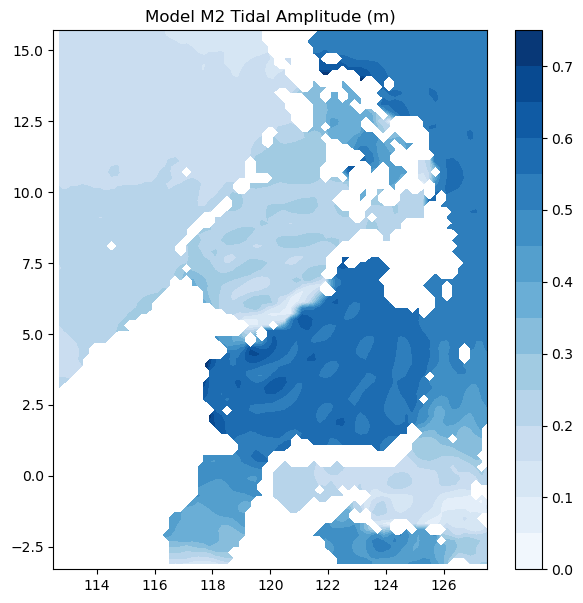

In [ ]:
# ds_tide.amp_m2.where(ds_tide.pha_m2!=0).plot.contourf(levels=np.arange(0,0.8,0.05),vmax=0.75)

plt.figure(figsize=(7,7))
plt.contourf(lontide,lattide,ds_tide.amp_m2.where(ds_tide.pha_m2!=0),levels=np.arange(0,0.8,0.05),vmax=0.75,cmap='Blues')
plt.colorbar()
plt.title('Model M2 Tidal Amplitude (m)')
# plt.contour(lontide,lattide,ds_tide.amp_m2.where(ds_tide.pha_m2!=0),levels=np.arange(0,0.8,0.1),colors='k')

Text(0.5, 1.0, 'Model M2 Tidal Phase (degree)')

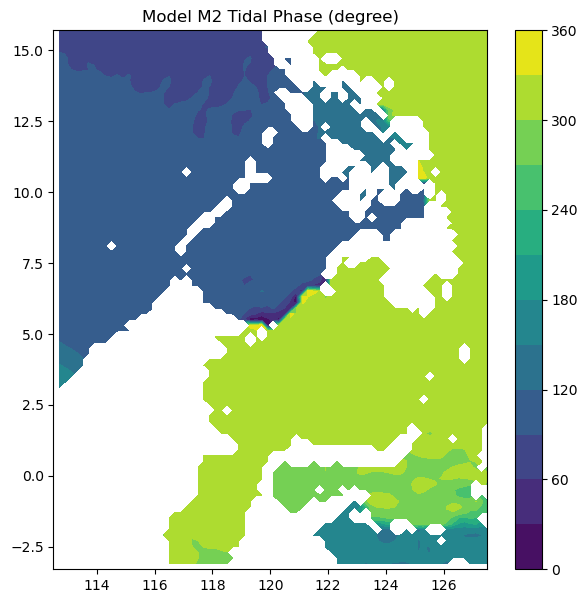

In [ ]:
pha_plt = ds_tide.pha_m2.where(ds_tide.pha_m2!=0).values
# pha_plt2 = ds_tide.pha_m2.where(ds_tide.pha_m2!=0)
# pha_plt2[pha_plt<180] = pha_plt+180
# pha_plt2[pha_plt>=180] = pha_plt-180
pha_plt2 = np.where(pha_plt<210,pha_plt+150,pha_plt-210)
# pha_plt2 = pha_plt2.where(pha_plt>=180,pha_plt-180)

# ds_tide.pha_m2.where(ds_tide.pha_m2!=0).plot(levels=np.arange(0,375,30))
plt.figure(figsize=(7,7))
plt.contourf(lontide,lattide,pha_plt2,levels=np.arange(0,375,30))
plt.colorbar()
plt.title('Model M2 Tidal Phase (degree)')

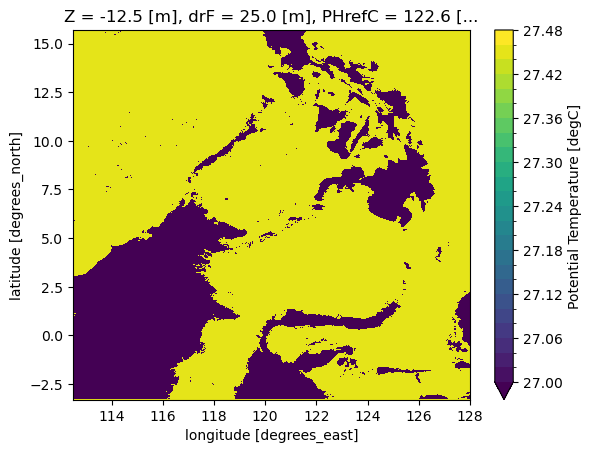

In [ ]:
ds_sn.THETA.isel(time=0,Z=0).plot(levels=np.arange(27,27.5,0.02))

(116.0, 122.0)

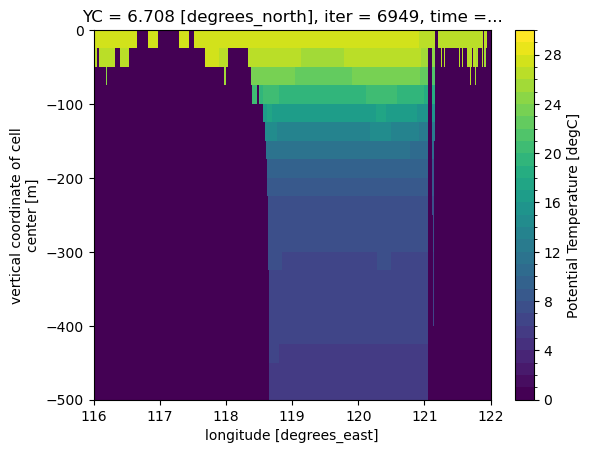

In [ ]:
ds_sn.THETA.isel(time=128,YC=600).plot.pcolormesh(levels = np.arange(0,31,1))
plt.ylim(-500,0)
plt.xlim(116,122)

# vertical sections

In [ ]:
x0 = np.linspace(112.508333333333333,127.99166666666666667,930)
y0 = np.linspace(-3.2916666666666667,15.691666666666666667,1140)
xmodel,ymodel = np.meshgrid(x0,y0)

In [ ]:
from scipy.interpolate import RegularGridInterpolator
spacing = 0.005  # about 0.3 minutes

theta_sec_tseries = []
for it in range(129):
    print(it)
    theta_sec1 = []
    for ik in range(57):
    
        t0 = ds_sn.THETA.isel(time=it, Z=ik).values.T
        t0[t0==0] = np.nan
        interp_func = RegularGridInterpolator((x0,y0), t0)
        
        # Section 1: (118°E, 10°N) to (121°E, 6°N)
        xsec1 = np.arange(118.5, 121+spacing, spacing)
        ysec1 = np.arange(9.333333333333334, 6-spacing, -spacing)
        if len(xsec1) != len(ysec1):
            points_needed = min(len(xsec1), len(ysec1))
            xsec1 = np.linspace(118.5, 121, points_needed)
            ysec1 = np.linspace(9.333333333333334, 6, points_needed)
        pts_sec1 = (xsec1, ysec1)
        
        theta_sec1.append(interp_func(pts_sec1))
    theta_sec1 = np.array(theta_sec1)
    theta_sec_tseries.append(theta_sec1)
theta_sec1_tseries = np.array(theta_sec1_tseries)

# distances_sec1 = np.sqrt((xsec1-xsec1[0])**2 + (ysec1-ysec1[0])**2) * 111

# # Extract water depths along each section directly from toposulu dataset
# depths_sec1 = np.zeros((57,len(xsec1)))

# # For each point in each section, find the nearest data point in toposulu
# for ik in range(57):
#     print(ik)
#     for i in range(len(xsec1)):
#         depths_sec1[ik,i] = ds_sn.THETA.isel(time=-1, Z=ik).sel(XC=xsec1[i], YC=ysec1[i], method='nearest').values

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128


In [ ]:
theta_sec1 = np.array(theta_sec1)

(-500.0, 0.0)

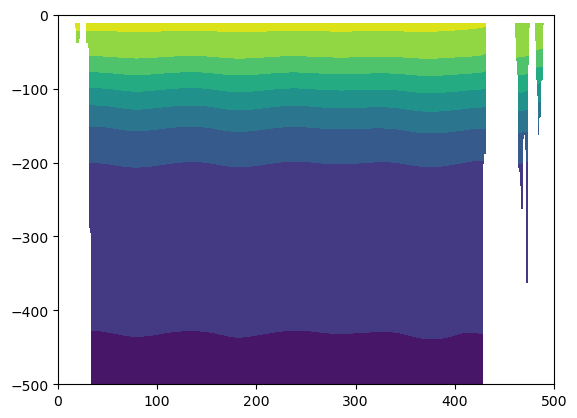

In [ ]:
plt.contourf(range(len(xsec1)),ds_sn.Z,theta_sec1)
plt.ylim(-500,0)

# vertical profile in Sulu

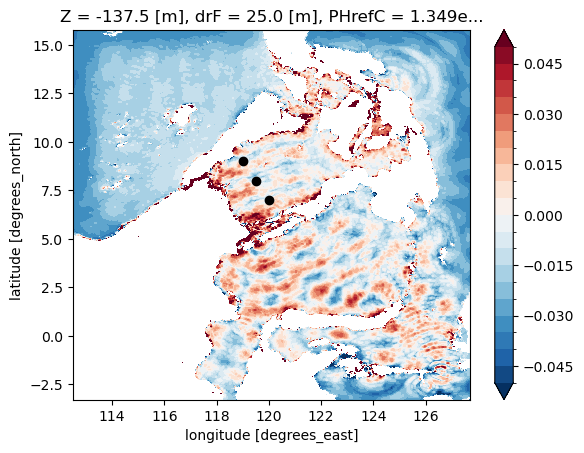

In [ ]:
(t_case.isel(time=190).where(t_case.isel(time=it)!=0)-tref.isel(t=190)).plot.contourf(levels=np.arange(-0.05,0.052,0.005))
plt.plot(120,7,'ok')
plt.plot(119.5,8,'ok')
plt.plot(119,9,'ok')

In [ ]:
ncase = ['075','033','050','150','200','250']
nt = 570

prf_folder = f'case_ctrl/profiles/'
    
try:
    os.makedirs(prf_folder, exist_ok=True)
    print(f"Folder '{prf_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{prf_folder}' : {e}.")
    
for it in tqdm(range(nt)):
    ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/',read_grid=False, 
                                   prefix=['outs_sn'], iters=[it*180])
    ds_profile1 = ds_0.isel(j=1030,i=750,j_g=1030,i_g=750)
    ds_profile2 = ds_0.isel(j=1130,i=700,j_g=1130,i_g=700)
    ds_profile3 = ds_0.isel(j=1230,i=650,j_g=1230,i_g=650)

    ds_profile1.to_netcdf(f'{prf_folder}profile1_yc1030_xc750.nc')
    ds_profile2.to_netcdf(f'{prf_folder}profile2_yc1130_xc700.nc')
    ds_profile3.to_netcdf(f'{prf_folder}profile3_yc1230_xc650.nc')


for icase in ncase:

    prf_folder = f'case_N2_fac_{icase}/profiles/'
    
    try:
        os.makedirs(prf_folder, exist_ok=True)
        print(f"Folder '{prf_folder}' created.")
    except OSError as e:
        print(f"Error creating dir '{prf_folder}' : {e}.")
        
    for it in tqdm(range(nt)):
        ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',read_grid=False, 
                                       prefix=['outs_sn'], iters=[it*180])
        ds_profile1 = ds_0.isel(j=1030,i=750,j_g=1030,i_g=750)
        ds_profile2 = ds_0.isel(j=1130,i=700,j_g=1130,i_g=700)
        ds_profile3 = ds_0.isel(j=1230,i=650,j_g=1230,i_g=650)
    
        ds_profile1.to_netcdf(f'{prf_folder}profile1_yc1030_xc750.nc')
        ds_profile2.to_netcdf(f'{prf_folder}profile2_yc1130_xc700.nc')
        ds_profile3.to_netcdf(f'{prf_folder}profile3_yc1230_xc650.nc')


Folder 'case_ctrl/profiles/' created.


100%|██████████| 570/570 [2:02:59<00:00, 12.95s/it]  


Folder 'case_N2_fac_075/profiles/' created.


100%|██████████| 570/570 [1:59:54<00:00, 12.62s/it]  


Folder 'case_N2_fac_033/profiles/' created.


100%|██████████| 570/570 [1:53:47<00:00, 11.98s/it]


Folder 'case_N2_fac_050/profiles/' created.


  1%|          | 3/570 [00:32<1:47:26, 11.37s/it]

In [ ]:
prf_folder = f'case_N2_fac_{icase}/profiles/'

try:
    os.makedirs(prf_folder, exist_ok=True)
    print(f"Folder '{prf_folder}' created.")
except OSError as e:
    print(f"Error creating dir '{prf_folder}' : {e}.")

ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',read_grid=False, 
                                   prefix=['outs_sn'])

# t_profile1 = ds_0.isel(j=1030,i=750,j_g=1030,i_g=750).THETA.values
# t_profile2 = ds_0.isel(j=1130,i=700,j_g=1130,i_g=700).THETA.values
t_profile3 = ds_0.isel(j=1230,i=650,j_g=1230,i_g=650).THETA.values

# t_profile1 = np.array(t_profile1)
# t_profile2 = np.array(t_profile2)
t_profile3 = np.array(t_profile3)

# np.save(f'case_N2_fac_{icase}/profiles/temp_profile1_yc1030_xc750.pny',t_profile1)
# np.save(f'case_N2_fac_{icase}/profiles/temp_profile2_yc1130_xc700.pny',t_profile2)
np.save(f'case_N2_fac_{icase}/profiles/temp_profile3_yc1230_xc650.pny',t_profile3)

Folder 'case_N2_fac_075/profiles/' created.


In [ ]:
ds_0 = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_N2_fac_{icase}/',read_grid=False, 
                                   prefix=['outs_sn'])
print('U profile 1')
u_profile1 = ds_0.isel(j=1030,i_g=750).UVEL.values
print('U profile 2')
u_profile2 = ds_0.isel(j=1130,i_g=700).UVEL.values
print('U profile 3')
u_profile3 = ds_0.isel(j=1230,i_g=650).UVEL.values
print('V profile 1')
v_profile1 = ds_0.isel(j_g=1030,i=750).VVEL.values
print('V profile 2')
v_profile2 = ds_0.isel(j_g=1130,i=700).VVEL.values
print('V profile 3')
v_profile3 = ds_0.isel(j_g=1230,i=650).VVEL.values

print('Save to npy files')
u_profile1 = np.array(u_profile1)
u_profile2 = np.array(u_profile2)
u_profile3 = np.array(u_profile3)
v_profile1 = np.array(v_profile1)
v_profile2 = np.array(v_profile2)
v_profile3 = np.array(v_profile3)

np.save(f'case_N2_fac_{icase}/profiles/uvel_profile1_yc1030_xc750.pny',u_profile1)
np.save(f'case_N2_fac_{icase}/profiles/uvel_profile2_yc1130_xc700.pny',u_profile2)
np.save(f'case_N2_fac_{icase}/profiles/uvel_profile3_yc1230_xc650.pny',u_profile3)
np.save(f'case_N2_fac_{icase}/profiles/vvel_profile1_yc1030_xc750.pny',v_profile1)
np.save(f'case_N2_fac_{icase}/profiles/vvel_profile2_yc1130_xc700.pny',v_profile2)
np.save(f'case_N2_fac_{icase}/profiles/vvel_profile3_yc1230_xc650.pny',v_profile3)

U profile 1


KeyboardInterrupt: 

In [ ]:
ds_0

<xarray.Dataset> Size: 2TB
Dimensions:  (time: 575, k: 57, j: 1908, i_g: 1520, j_g: 1908, i: 1520,
              k_l: 57, k_u: 57, k_p1: 58)
Coordinates:
    iter     (time) int64 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * i        (i) int64 12kB 0 1 2 3 4 5 6 ... 1513 1514 1515 1516 1517 1518 1519
  * i_g      (i_g) int64 12kB 0 1 2 3 4 5 6 ... 1514 1515 1516 1517 1518 1519
  * j        (j) int64 15kB 0 1 2 3 4 5 6 ... 1901 1902 1903 1904 1905 1906 1907
  * j_g      (j_g) int64 15kB 0 1 2 3 4 5 6 ... 1902 1903 1904 1905 1906 1907
  * k        (k) int64 456B 0 1 2 3 4 5 6 7 8 9 ... 48 49 50 51 52 53 54 55 56
  * k_u      (k_u) int64 456B 0 1 2 3 4 5 6 7 8 9 ... 48 49 50 51 52 53 54 55 56
  * k_l      (k_l) int64 456B 0 1 2 3 4 5 6 7 8 9 ... 48 49 50 51 52 53 54 55 56
  * k_p1     (k_p1) int64 464B 0 1 2 3 4 5 6 7 8 ... 49 50 51 52 53 54 55 56 57
  * time     (time) timedelta64[ns] 5kB 00:00:00 00:03:00 ... 1 days 04:42:00
Data variables:
    UVEL     (time, k, j, i_g) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    VVEL     (time, k, j_g, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    WVEL     (time, k_l, j, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    THETA    (time, k, j, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
    PHIHYD   (time, k, j, i) float32 380GB dask.array<chunksize=(1, 57, 1908, 1520), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm

In [ ]:
# temp_profile1 = ds_sn.THETA.isel(YC=1030,XC=750).values
# temp_profile2 = ds_sn.THETA.isel(YC=1130,XC=700).values
# temp_profile3 = ds_sn.THETA.isel(YC=1230,XC=650).values

In [ ]:
# temp_profile1.to_netcdf(f'case_N2_fac_{icase}/temp_profile1_yc1030_xc750.nc')
# temp_profile2.to_netcdf(f'case_N2_fac_{icase}/temp_profile2_yc1130_xc700.nc')
# temp_profile3.to_netcdf(f'case_N2_fac_{icase}/temp_profile3_yc1230_xc650.nc')

In [ ]:
zprofile = ds_sn.Z
tprofile = ds_sn.time

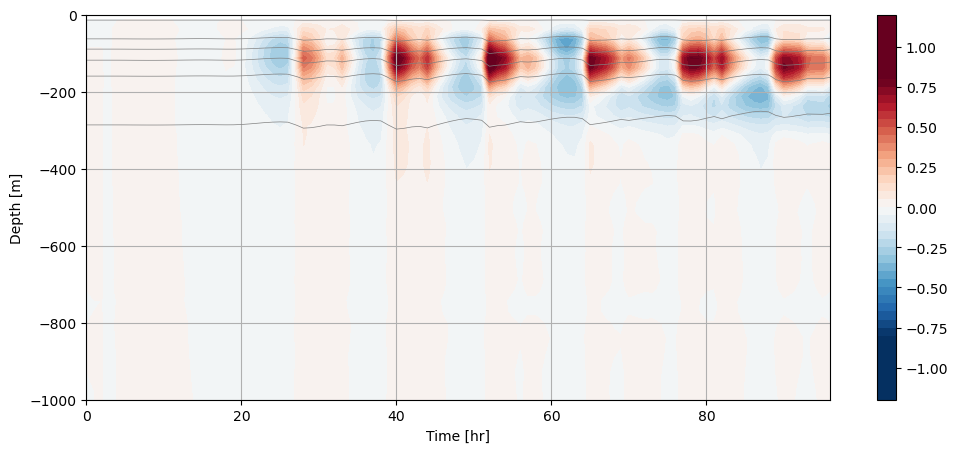

In [ ]:
plt.figure(figsize=(12,5))
plt.contourf(np.arange(97), zprofile, (temp_profile1-temp_profile1[0,:]).T,cmap='RdBu_r',vmax=0.8, vmin=-0.8,
              levels=np.arange(-1.2,1.25,0.05))
plt.ylim(-1000,0)
plt.xlabel('Time [hr]')
plt.ylabel('Depth [m]')
plt.grid('on')
plt.colorbar()
plt.contour(np.arange(97), zprofile, (temp_profile1).T,colors='gray',linewidths=.5)

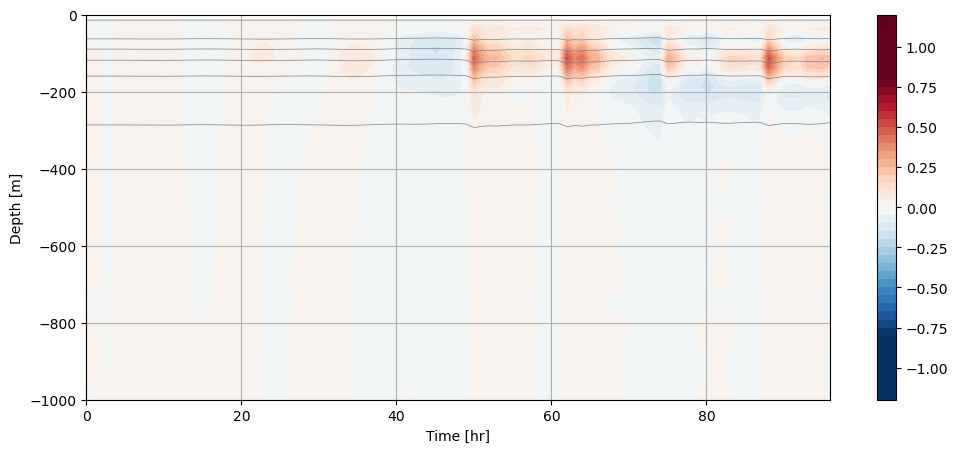

In [ ]:
plt.figure(figsize=(12,5))
plt.contourf(np.arange(97), zprofile, (temp_profile2-temp_profile2[0,:]).T,cmap='RdBu_r',vmax=0.8, vmin=-0.8,
              levels=np.arange(-1.2,1.25,0.05))
plt.ylim(-1000,0)
plt.xlabel('Time [hr]')
plt.ylabel('Depth [m]')
plt.grid('on')
plt.colorbar()
plt.contour(np.arange(97), zprofile, (temp_profile2).T,colors='gray',linewidths=.5)

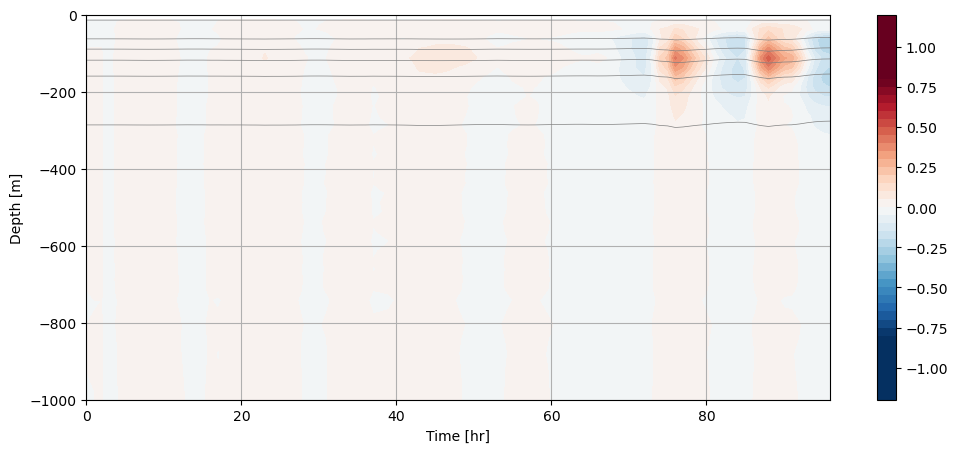

In [ ]:
plt.figure(figsize=(12,5))
plt.contourf(np.arange(97), zprofile, (temp_profile3-temp_profile3[0,:]).T,cmap='RdBu_r',vmax=0.8, vmin=-0.8,
              levels=np.arange(-1.2,1.25,0.05))
plt.colorbar()
plt.contour(np.arange(97), zprofile, (temp_profile3).T,colors='gray',linewidths=.5)
plt.ylim(-1000,0)
plt.xlabel('Time [hr]')
plt.ylabel('Depth [m]')
plt.grid('on')

## Vertical profile - v2

In [ ]:
# ds_profile1 = xr.open_dataset('exp7_results/temp_profile1_yc1030_xc750.nc')
# ds_profile2 = xr.open_dataset('exp7_results/temp_profile2_yc1130_xc700.nc')
# ds_profile3 = xr.open_dataset('exp7_results/temp_profile3_yc1230_xc650.nc')

# temp_profile1 = ds_profile1.THETA.values
# temp_profile2 = ds_profile2.THETA.values
# temp_profile3 = ds_profile3.THETA.values
t_case = ds_sn.THETA.isel(time = slice(0,nt),Z=5)
# tref
for it in tqdm(range(nt)):
    ds_tref0 = xr.open_dataset(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc')
    if it==0:
        ds_tref = ds_tref0
    else:
        ds_tref = xr.concat([ds_tref,ds_tref0],"t")

ds_tref['t'] = ds_sn.time[0:nt]
# ds_tref
tref = ds_tref.theta_ref
# ds_tref = xr.open_dataset('theta_ref/theta_ref_exp8_small_tide_0.01.nc')
# # ds_tref
# tref = ds_tref.theta_ref.values

tanom_to_tref_1 = t_profile1-tref
tanom_to_tref_2 = t_profile2[0:570,:]-tref
tanom_to_tref_3 = t_profile3[0:570,:]-tref

100%|██████████| 570/570 [00:05<00:00, 112.83it/s]


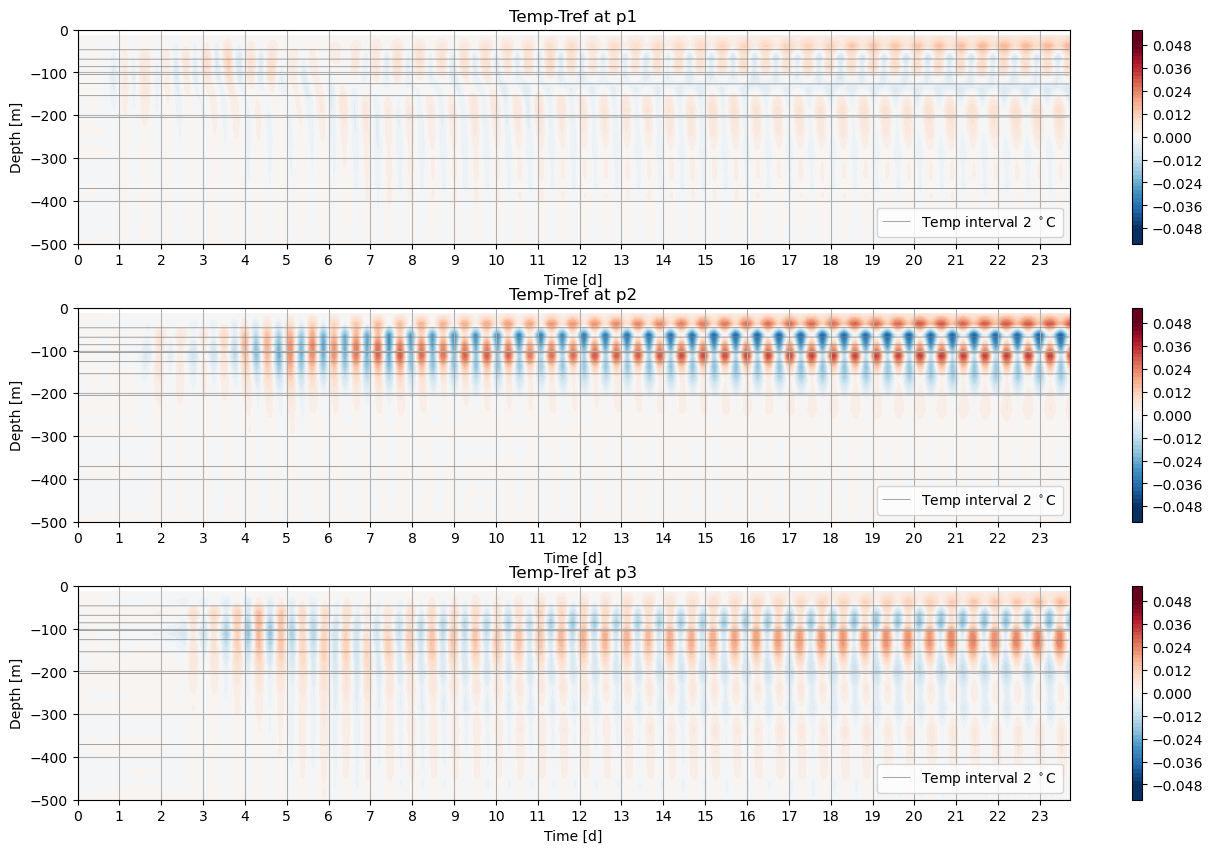

In [ ]:


figure, ax = plt.subplots(3,1,figsize=(16,10))
cnt2 = ax[0].contourf(np.arange(nt), zprofile, tanom_to_tref_1.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[0].set_ylim(-500,0)
ax[0].set_xticks(range(0,nt,24))
ax[0].set_xticklabels(range(0,24,1))
# plt.xlim(500,659)
ax[0].set_xlabel('Time [d]')
ax[0].set_ylabel('Depth [m]')
ax[0].grid('on')
figure.colorbar(cnt2,ax=ax[0])
cnt1 = ax[0].contour(np.arange(nt), zprofile, (t_profile1).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[0].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[0].set_title('Temp-Tref at p1')

cnt2 = ax[1].contourf(np.arange(nt), zprofile, tanom_to_tref_2.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[1].set_ylim(-500,0)
ax[1].set_xticks(range(0,nt,24))
ax[1].set_xticklabels(range(0,24,1))
# plt.xlim(500,659)
ax[1].set_xlabel('Time [d]')
ax[1].set_ylabel('Depth [m]')
ax[1].grid('on')
figure.colorbar(cnt2,ax=ax[1])
cnt1 = ax[1].contour(np.arange(nt), zprofile, (t_profile2[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[1].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[1].set_title('Temp-Tref at p2')

cnt2 = ax[2].contourf(np.arange(nt), zprofile, tanom_to_tref_3.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[2].set_ylim(-500,0)
ax[2].set_xticks(range(0,nt,24))
ax[2].set_xticklabels(range(0,24,1))
# plt.xlim(500,659)
ax[2].set_xlabel('Time [d]')
ax[2].set_ylabel('Depth [m]')
ax[2].grid('on')
figure.colorbar(cnt2,ax=ax[2])
cnt1 = ax[2].contour(np.arange(nt), zprofile, (t_profile3[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[2].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[2].set_title('Temp-Tref at p3')
plt.subplots_adjust(hspace=0.3,)


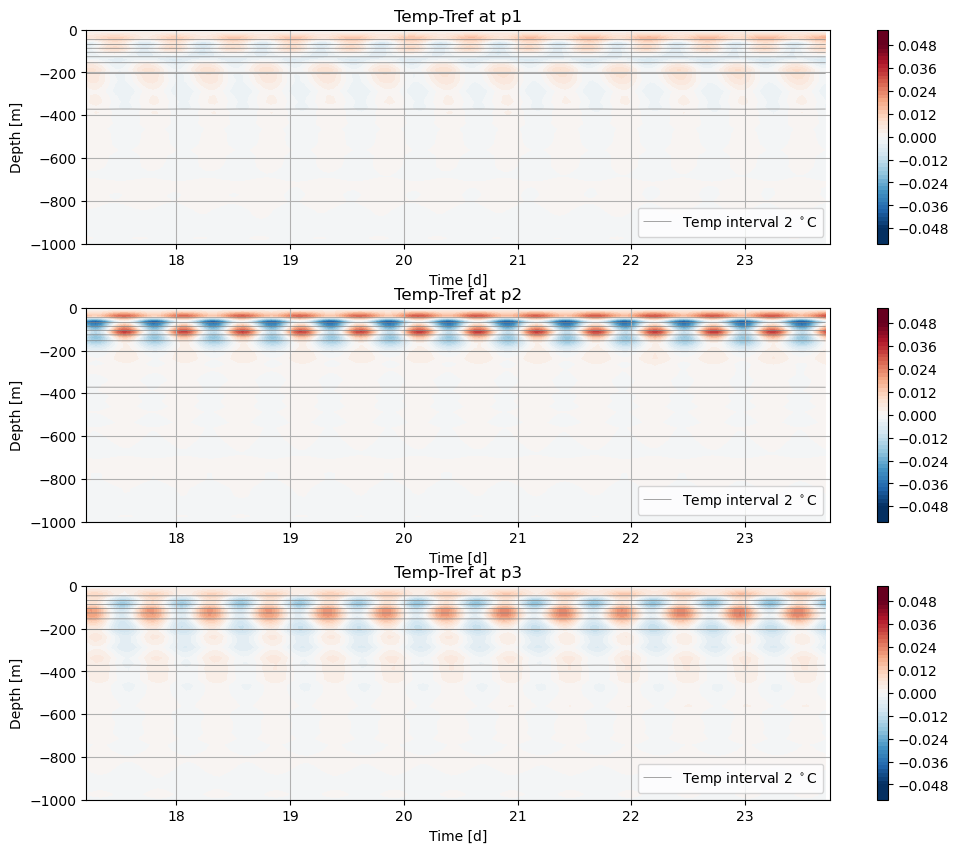

In [ ]:
figure, ax = plt.subplots(3,1,figsize=(12,10))
cnt2 = ax[0].contourf(np.arange(nt), zprofile, tanom_to_tref_1.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[0].set_ylim(-1000,0)
ax[0].set_xticks(range(0,nt,24))
ax[0].set_xticklabels(range(0,24,1))
ax[0].set_xlim(413,nt)
ax[0].set_xlabel('Time [d]')
ax[0].set_ylabel('Depth [m]')
ax[0].grid('on')
figure.colorbar(cnt2,ax=ax[0])
cnt1 = ax[0].contour(np.arange(nt), zprofile, (t_profile1).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[0].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[0].set_title('Temp-Tref at p1')

cnt2 = ax[1].contourf(np.arange(nt), zprofile, tanom_to_tref_2.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[1].set_ylim(-1000,0)
ax[1].set_xticks(range(0,nt,24))
ax[1].set_xticklabels(range(0,24,1))
ax[1].set_xlim(413,nt)
ax[1].set_xlabel('Time [d]')
ax[1].set_ylabel('Depth [m]')
ax[1].grid('on')
figure.colorbar(cnt2,ax=ax[1])
cnt1 = ax[1].contour(np.arange(nt), zprofile, (t_profile2[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[1].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[1].set_title('Temp-Tref at p2')

cnt2 = ax[2].contourf(np.arange(nt), zprofile, tanom_to_tref_3.T,cmap='RdBu_r',vmax=1.2*0.04, vmin=-1.2*0.04,
              levels=np.arange(-1.4,1.45,0.05)*0.04)
ax[2].set_ylim(-1000,0)
ax[2].set_xticks(range(0,nt,24))
ax[2].set_xticklabels(range(0,24,1))
ax[2].set_xlim(413,nt)
ax[2].set_xlabel('Time [d]')
ax[2].set_ylabel('Depth [m]')
ax[2].grid('on')
figure.colorbar(cnt2,ax=ax[2])
cnt1 = ax[2].contour(np.arange(nt), zprofile, (t_profile3[0:570]).T,levels=np.arange(0,30,2),colors='grey',linewidths=.5)
h1,_ = cnt1.legend_elements()
# h2,_ = cnt2.legend_elements()
ax[2].legend([h1[0]], ['Temp interval 2 $^\circ$C'], loc='lower right')
ax[2].set_title('Temp-Tref at p3')
plt.subplots_adjust(hspace=0.3,)
